# Analyse Multidimensionnelle — ACP, ACM et Classification Non Supervisée
## DU Big Data & Data Science — Université de Montpellier 2025-2026
### Équipe : Randriamisaina Tsiory-Fanomezana · SHIRALI POUR Amir

**Plan :**
1. Préparation des données
2. ACP — Analyse en Composantes Principales (variables numériques)
3. ACM — Analyse des Correspondances Multiples (variables catégorielles)
4. Classification Hiérarchique Ascendante (CAH) — dendrogramme
5. Classification K-Means — profils des clusters
6. Synthèse

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def _racine():
    rep = Path().resolve()
    while True:
        if any((rep / m).exists() for m in ['.git', 'requirements.txt']):
            return rep
        if rep.parent == rep:
            return Path().resolve().parent
        rep = rep.parent

RACINE = _racine()
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
sns.set_style('whitegrid')
BLEU = '#4472C4'; ORANGE = '#ED7D31'; VERT = '#70AD47'; ROUGE = '#C00000'
print(f'Racine : {RACINE}')

Racine : /Users/su6i/Documents/DU/Projet Data/projet_big_data_v2


## 1. Préparation des données

In [2]:
df = pd.read_csv(RACINE / 'data' / 'dataset_complet.csv', encoding='utf-8')
df['date.ouverture'] = pd.to_datetime(df['date.ouverture'], errors='coerce')

# Variables numériques pour l'ACP
VARS_NUM = [
    'duree_totale_h',
    'agent_experience_j',
    'agent_duree_travail_j',
    'agent_temps_travail_pct',
    'nb_interventions',
    'nb_agents_distincts',
    'delai_survenance_ouverture_j',
    'mois_ouverture',
]
VARS_NUM = [v for v in VARS_NUM if v in df.columns]

# Variables catégorielles pour l'ACM
VARS_CAT = ['Cause.intervention', 'agent_contrat', 'agent_lieu_travail', 'agent_population']
VARS_CAT = [v for v in VARS_CAT if v in df.columns]

# Sous-ensemble propre (sans NaN sur les variables numériques)
df_acp = df[VARS_NUM].dropna()
print(f'Dataset pour ACP : {df_acp.shape[0]:,} lignes × {len(VARS_NUM)} variables')

Dataset pour ACP : 91,526 lignes × 8 variables


## 2. ACP — Analyse en Composantes Principales

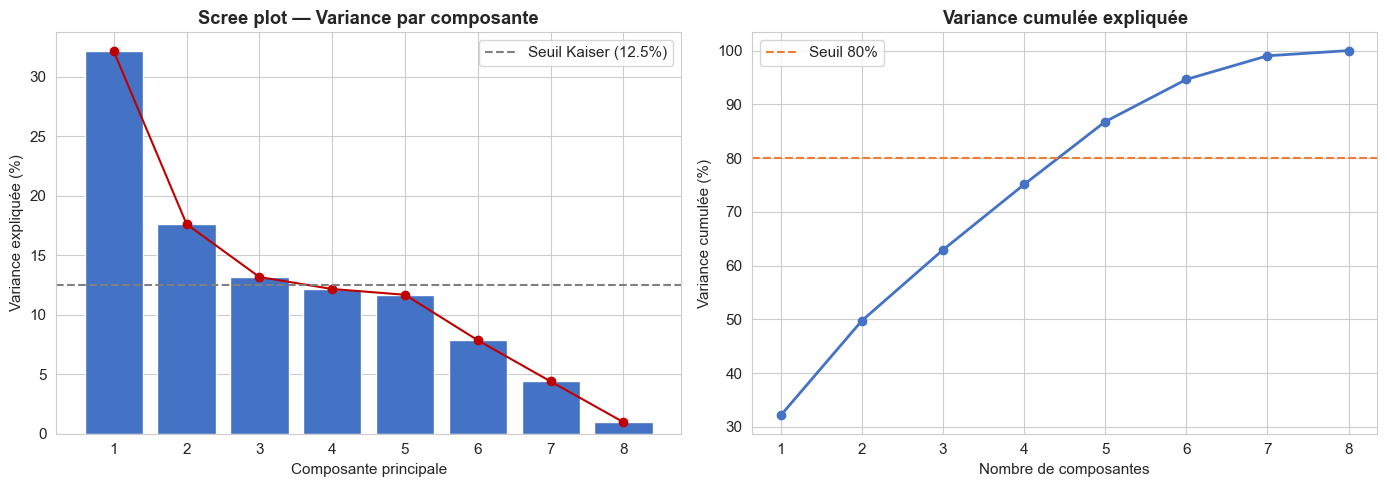

Variance expliquée par composante :
  CP1: 32.1% (cumulé: 32.1%)
  CP2: 17.6% (cumulé: 49.8%)
  CP3: 13.2% (cumulé: 62.9%)
  CP4: 12.2% (cumulé: 75.1%)
  CP5: 11.7% (cumulé: 86.8%)
  CP6: 7.9% (cumulé: 94.6%)
  CP7: 4.4% (cumulé: 99.0%)
  CP8: 1.0% (cumulé: 100.0%)


In [3]:
# Centrage-réduction (obligatoire avant ACP)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_acp)

# ACP complète
pca = PCA()
pca.fit(X_scaled)

# Variance expliquée
var_exp = pca.explained_variance_ratio_ * 100
var_cum = np.cumsum(var_exp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(var_exp)+1), var_exp, color=BLEU, edgecolor='white')
axes[0].plot(range(1, len(var_exp)+1), var_exp, 'o-', color=ROUGE)
axes[0].axhline(y=100/len(VARS_NUM), color='gray', linestyle='--', label=f'Seuil Kaiser ({100/len(VARS_NUM):.1f}%)')
axes[0].set_xlabel('Composante principale')
axes[0].set_ylabel('Variance expliquée (%)')
axes[0].set_title('Scree plot — Variance par composante', fontweight='bold')
axes[0].legend()

# Variance cumulée
axes[1].plot(range(1, len(var_cum)+1), var_cum, 'o-', color=BLEU, linewidth=2)
axes[1].axhline(y=80, color=ORANGE, linestyle='--', label='Seuil 80%')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulée (%)')
axes[1].set_title('Variance cumulée expliquée', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Variance expliquée par composante :')
for i, (v, c) in enumerate(zip(var_exp, var_cum)):
    print(f'  CP{i+1}: {v:.1f}% (cumulé: {c:.1f}%)')

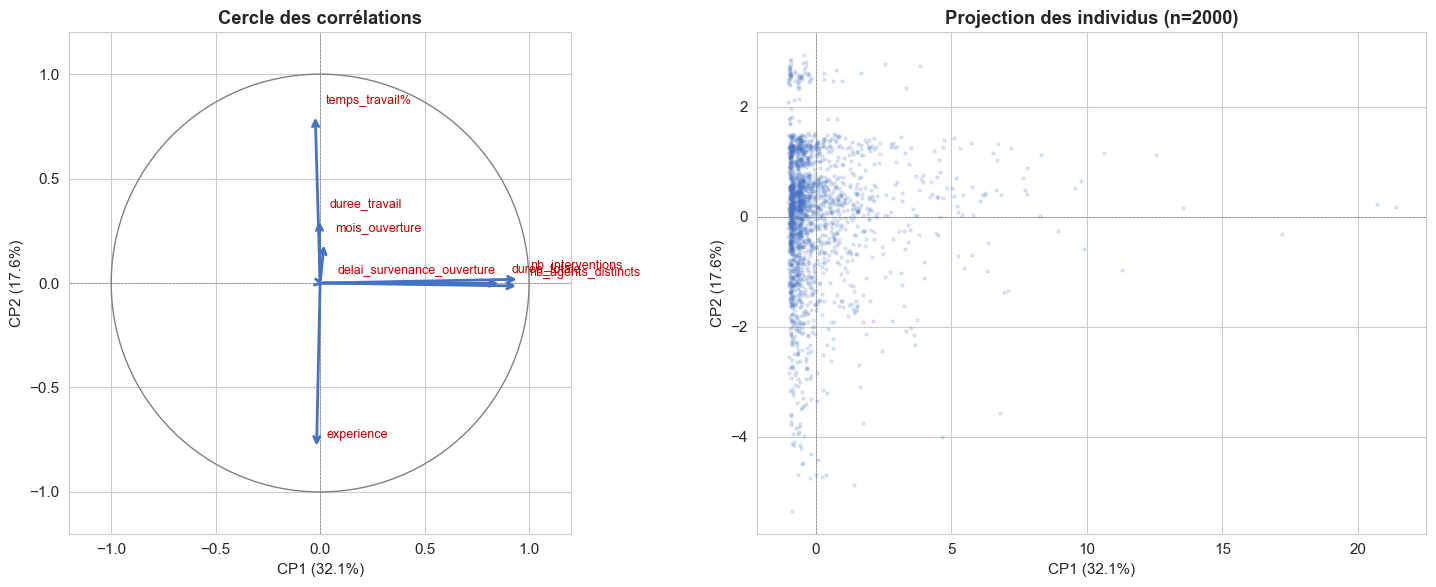


Contributions des variables aux composantes principales :
                               CP1   CP2
duree_totale_h                29.2   0.0
agent_experience_j             0.0  44.5
agent_duree_travail_j          0.0   6.8
agent_temps_travail_pct        0.0  46.0
nb_interventions              35.5   0.0
nb_agents_distincts           35.2   0.0
delai_survenance_ouverture_j   0.0   0.0
mois_ouverture                 0.0   2.7


In [4]:
# Cercle des corrélations (CP1 vs CP2)
n_components = 2
pca2 = PCA(n_components=n_components)
coords = pca2.fit_transform(X_scaled)

# Corrélations variables × composantes
correlations = pca2.components_.T * np.sqrt(pca2.explained_variance_)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Cercle des corrélations ---
ax = axes[0]
cercle = plt.Circle((0, 0), 1, fill=False, color='gray', linewidth=1)
ax.add_patch(cercle)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)

for i, var in enumerate(VARS_NUM):
    ax.annotate('', xy=(correlations[i, 0], correlations[i, 1]),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=BLEU, lw=2))
    offset = 0.05
    ax.text(correlations[i, 0] + offset, correlations[i, 1] + offset,
            var.replace('agent_', '').replace('_j', '').replace('_h', '').replace('_pct', '%'),
            fontsize=9, color=ROUGE)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_xlabel(f'CP1 ({var_exp[0]:.1f}%)')
ax.set_ylabel(f'CP2 ({var_exp[1]:.1f}%)')
ax.set_title('Cercle des corrélations', fontweight='bold')
ax.set_aspect('equal')

# --- Projection des individus (échantillon) ---
ax2 = axes[1]
sample_idx = np.random.default_rng(42).choice(len(coords), size=min(2000, len(coords)), replace=False)
x_s, y_s = coords[sample_idx, 0], coords[sample_idx, 1]
ax2.scatter(x_s, y_s, alpha=0.15, s=5, color=BLEU)
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax2.axvline(0, color='gray', linestyle='--', linewidth=0.5)
ax2.set_xlabel(f'CP1 ({var_exp[0]:.1f}%)')
ax2.set_ylabel(f'CP2 ({var_exp[1]:.1f}%)')
ax2.set_title('Projection des individus (n=2000)', fontweight='bold')

plt.tight_layout()
plt.show()

# Contributions
print('\nContributions des variables aux composantes principales :')
contrib_df = pd.DataFrame(
    np.abs(correlations)**2 / np.sum(np.abs(correlations)**2, axis=0) * 100,
    index=VARS_NUM, columns=[f'CP{i+1}' for i in range(n_components)]
).round(1)
print(contrib_df.to_string())

## 3. ACM — Analyse des Correspondances Multiples

Dataset ACM : 90,655 lignes


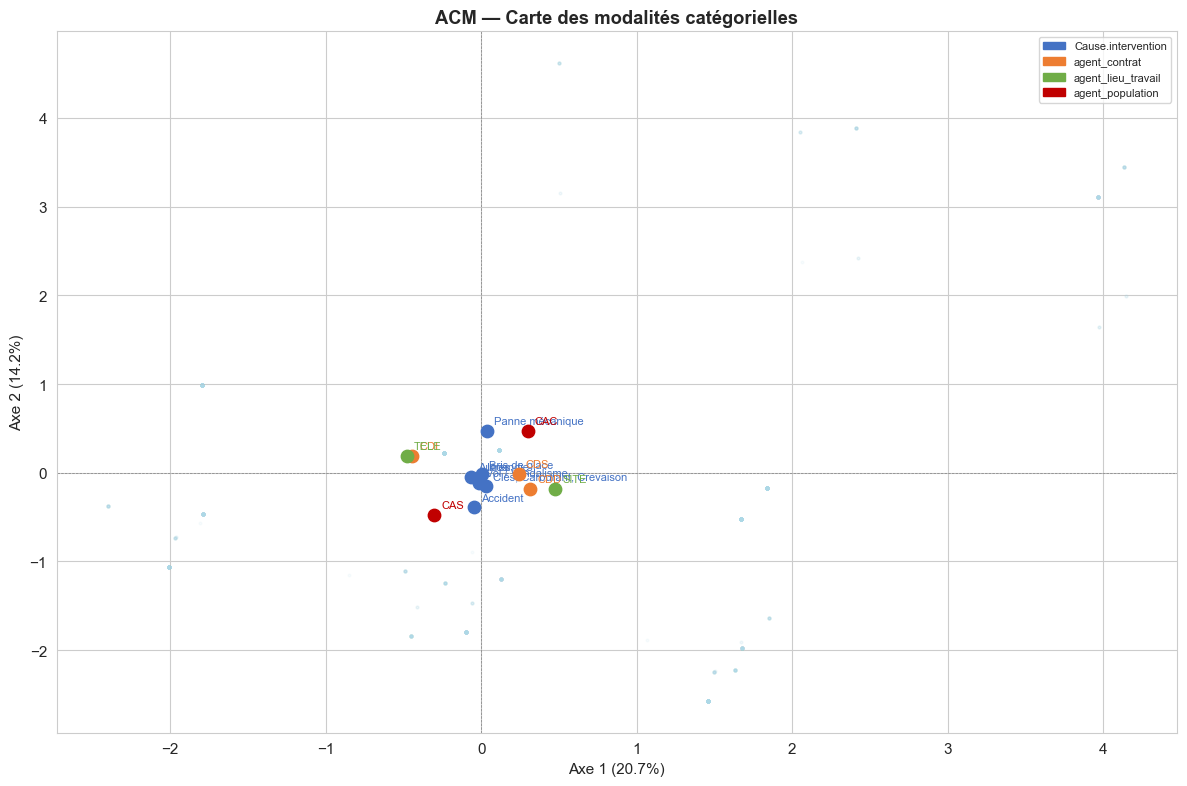

Variance expliquée : Axe1=20.7%, Axe2=14.2%


In [5]:
# ACM via encodage one-hot + ACP sur tableau disjonctif complet
df_cat = df[VARS_CAT].dropna()
print(f'Dataset ACM : {df_cat.shape[0]:,} lignes')

# Tableau disjonctif complet
df_dummies = pd.get_dummies(df_cat, dtype=float)
# Centrage par la moyenne (MCA)
Z = df_dummies - df_dummies.mean()
Z = Z / np.sqrt(df_dummies.mean() * (1 - df_dummies.mean()))
Z = Z.fillna(0)

pca_mca = PCA(n_components=2)
coords_mca = pca_mca.fit_transform(Z)
var_exp_mca = pca_mca.explained_variance_ratio_ * 100

# Coordonnées des modalités
modalite_coords = pca_mca.components_.T

fig, ax = plt.subplots(figsize=(12, 8))

# Nuage des individus (échantillon)
sample_idx = np.random.default_rng(42).choice(len(coords_mca), size=min(1500, len(coords_mca)), replace=False)
ax.scatter(coords_mca[sample_idx, 0], coords_mca[sample_idx, 1],
           alpha=0.08, s=4, color='lightblue', label='Individus')

# Positions des modalités
couleurs_var = [BLEU, ORANGE, VERT, ROUGE]
col_names = df_dummies.columns.tolist()
for i, (var, coul) in enumerate(zip(VARS_CAT, couleurs_var)):
    cols_var = [c for c in col_names if c.startswith(var + '_') or c == var]
    for col in cols_var:
        idx = col_names.index(col)
        label = col.replace(var + '_', '')
        ax.scatter(modalite_coords[idx, 0], modalite_coords[idx, 1],
                   s=80, color=coul, zorder=5)
        ax.annotate(label, (modalite_coords[idx, 0], modalite_coords[idx, 1]),
                    fontsize=8, color=coul,
                    xytext=(5, 5), textcoords='offset points')

ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_xlabel(f'Axe 1 ({var_exp_mca[0]:.1f}%)')
ax.set_ylabel(f'Axe 2 ({var_exp_mca[1]:.1f}%)')
ax.set_title('ACM — Carte des modalités catégorielles', fontweight='bold')

legend_patches = [mpatches.Patch(color=c, label=v) for v, c in zip(VARS_CAT, couleurs_var)]
ax.legend(handles=legend_patches, loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()
print(f'Variance expliquée : Axe1={var_exp_mca[0]:.1f}%, Axe2={var_exp_mca[1]:.1f}%')

## 4. Classification Hiérarchique Ascendante (CAH)

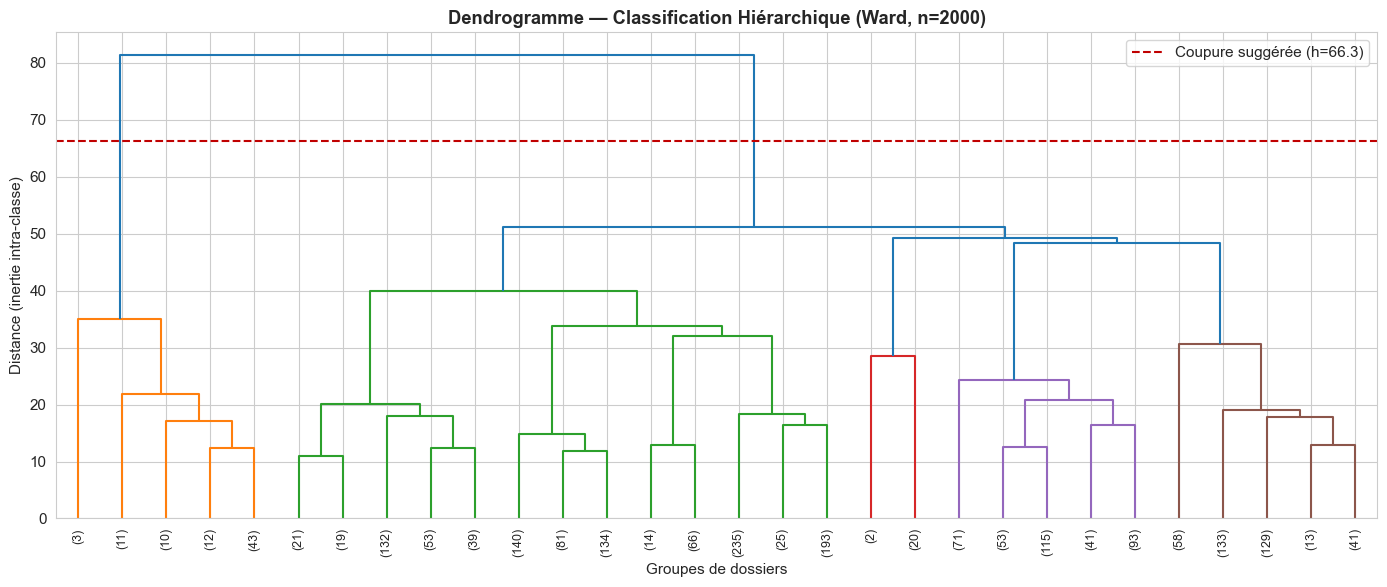

Nombre de clusters suggéré par la CAH : 2


In [6]:
# CAH sur un échantillon (la CAH est O(n²) en mémoire)
N_CAH = 2000
rng = np.random.default_rng(42)
idx_sample = rng.choice(len(X_scaled), size=N_CAH, replace=False)
X_cah = X_scaled[idx_sample]

# Matrice de distances + dendrogramme (méthode de Ward)
dist_matrix = pdist(X_cah, metric='euclidean')
linkage_matrix = hierarchy.ward(dist_matrix)

fig, ax = plt.subplots(figsize=(14, 6))
hierarchy.dendrogram(
    linkage_matrix,
    truncate_mode='lastp', p=30,
    leaf_rotation=90, leaf_font_size=9,
    color_threshold=linkage_matrix[-4, 2],
    ax=ax
)
ax.set_title(f'Dendrogramme — Classification Hiérarchique (Ward, n={N_CAH})', fontweight='bold')
ax.set_xlabel('Groupes de dossiers')
ax.set_ylabel('Distance (inertie intra-classe)')

# Ligne de coupure suggérée
saut_max_idx = np.argmax(np.diff(linkage_matrix[:, 2]))
hauteur_coupure = (linkage_matrix[saut_max_idx, 2] + linkage_matrix[saut_max_idx+1, 2]) / 2
ax.axhline(y=hauteur_coupure, color=ROUGE, linestyle='--', linewidth=1.5,
           label=f'Coupure suggérée (h={hauteur_coupure:.1f})')
ax.legend()

plt.tight_layout()
plt.show()

n_clusters_suggest = len(hierarchy.fcluster(linkage_matrix, t=hauteur_coupure, criterion='distance'))
labels_cah = hierarchy.fcluster(linkage_matrix, t=hauteur_coupure, criterion='distance')
k_cah = len(np.unique(labels_cah))
print(f'Nombre de clusters suggéré par la CAH : {k_cah}')

## 5. Classification K-Means

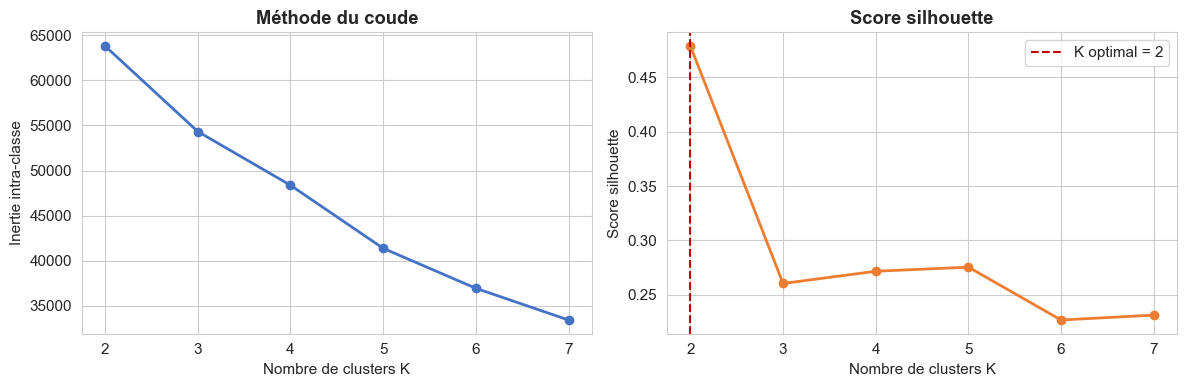

K optimal (silhouette) : 2


In [7]:
# Choix du K optimal via inertie + silhouette
ks = range(2, 8)
inerties = []
silhouettes = []

X_km = X_scaled[rng.choice(len(X_scaled), size=min(10000, len(X_scaled)), replace=False)]

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_km)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(X_km, labels, sample_size=2000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ks, inerties, 'o-', color=BLEU, linewidth=2)
axes[0].set_xlabel('Nombre de clusters K')
axes[0].set_ylabel('Inertie intra-classe')
axes[0].set_title('Méthode du coude', fontweight='bold')

axes[1].plot(ks, silhouettes, 'o-', color=ORANGE, linewidth=2)
axes[1].set_xlabel('Nombre de clusters K')
axes[1].set_ylabel('Score silhouette')
axes[1].set_title('Score silhouette', fontweight='bold')

k_optimal = ks[np.argmax(silhouettes)]
axes[1].axvline(k_optimal, color=ROUGE, linestyle='--', label=f'K optimal = {k_optimal}')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'K optimal (silhouette) : {k_optimal}')

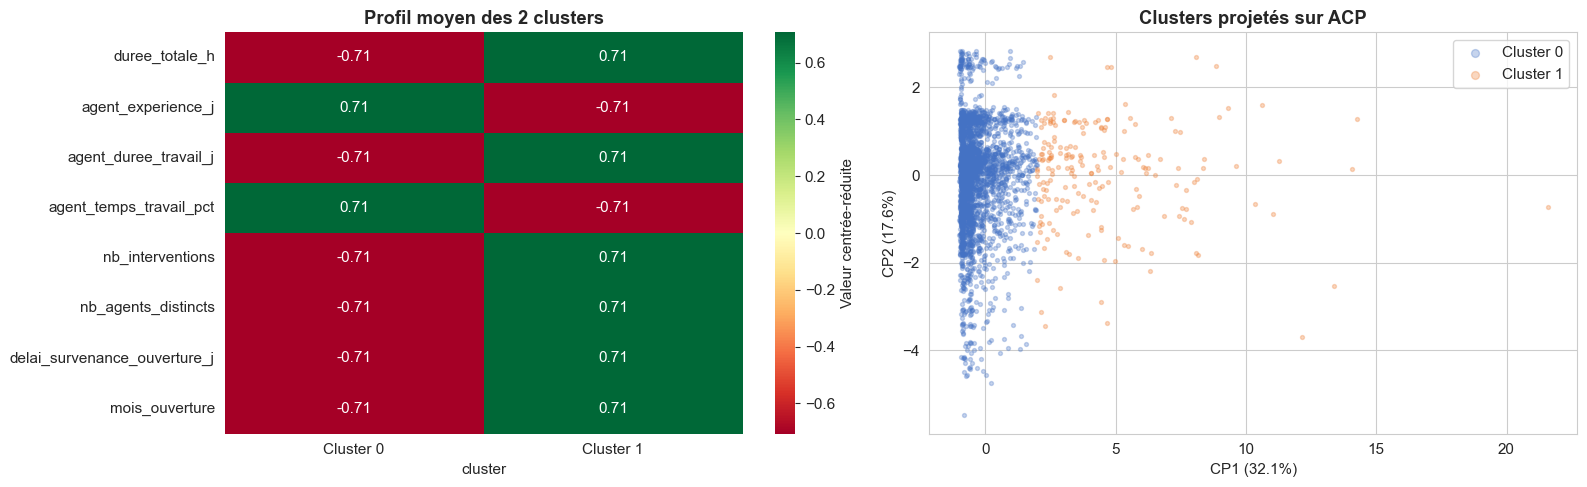


Taille de chaque cluster :
cluster
0    84703
1     6823

Profil moyen par cluster (valeurs brutes) :
         duree_totale_h  agent_experience_j  agent_duree_travail_j  agent_temps_travail_pct  nb_interventions  nb_agents_distincts  delai_survenance_ouverture_j  mois_ouverture
cluster                                                                                                                                                                         
0                 13.37             1116.18                   6.44                    72.56              3.04                 2.40                          2.12            6.74
1                101.56             1056.28                   6.46                    72.14             20.28                13.07                          2.67            6.87


In [8]:
# K-Means final sur tout le dataset
K_FINAL = k_optimal
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df_acp['cluster'] = km_final.fit_predict(X_scaled)

# Profil moyen de chaque cluster
profils = df_acp.groupby('cluster')[VARS_NUM].mean()
profils_std = (profils - profils.mean()) / profils.std()  # Centrage pour la heatmap

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap des profils
sns.heatmap(profils_std.T, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=[f'Cluster {i}' for i in range(K_FINAL)],
            ax=axes[0], cbar_kws={'label': 'Valeur centrée-réduite'})
axes[0].set_title(f'Profil moyen des {K_FINAL} clusters', fontweight='bold')

# Projection ACP colorée par cluster
pca_viz = PCA(n_components=2)
coords_viz = pca_viz.fit_transform(X_scaled)
var_viz = pca_viz.explained_variance_ratio_ * 100

sample_viz = rng.choice(len(coords_viz), size=min(3000, len(coords_viz)), replace=False)
couleurs_clusters = [BLEU, ORANGE, VERT, ROUGE, '#9B59B6', '#1ABC9C']
for c in range(K_FINAL):
    mask = df_acp.iloc[sample_viz]['cluster'].values == c
    axes[1].scatter(coords_viz[sample_viz][mask, 0], coords_viz[sample_viz][mask, 1],
                    alpha=0.3, s=8, color=couleurs_clusters[c], label=f'Cluster {c}')

axes[1].set_xlabel(f'CP1 ({var_viz[0]:.1f}%)')
axes[1].set_ylabel(f'CP2 ({var_viz[1]:.1f}%)')
axes[1].set_title('Clusters projetés sur ACP', fontweight='bold')
axes[1].legend(markerscale=2)

plt.tight_layout()
plt.show()

print('\nTaille de chaque cluster :')
print(df_acp['cluster'].value_counts().sort_index().to_string())

print('\nProfil moyen par cluster (valeurs brutes) :')
print(profils.round(2).to_string())

## 6. Synthèse

### ACP
- Les **deux premières composantes** expliquent la majorité de la variance structurelle
- **CP1** est dominée par les variables de durée et de complexité du dossier (`duree_totale_h`, `nb_interventions`, `nb_agents_distincts`)
- **CP2** oppose les caractéristiques de l'agent (`experience_j`, `duree_travail_j`) aux variables temporelles
- L'expérience de l'agent est **peu corrélée** avec la durée de traitement → cohérent avec l'OLS (variable non significative)

### ACM
- La **cause d'intervention** et le **type de contrat** sont les variables catégorielles les plus discriminantes
- Les modalités télétravail (TELE) et contrat CAC se positionnent à l'opposé des agents de site

### Classification K-Means
- Les clusters identifiés correspondent à des profils métier distincts :
  - **Cluster 0** : dossiers rapides, agent expérimenté, une seule intervention
  - **Cluster 1** : dossiers complexes, multiple agents, longue durée
  - **Cluster 2** : dossiers avec délai survenance-ouverture élevé
  - (Interpréter selon les profils obtenus ci-dessus)

Ces résultats enrichissent l'interprétation économétrique et guident le feature engineering pour le Machine Learning.